In [ ]:
# Add relevant Jupyter notebook cells below


In [ ]:
# You can double-check your Python path like this...
import sys  
print(sys.path)

['C:\\Users\\jonjo\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\jonjo\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\jonjo\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'C:\\Users\\jonjo\\AppData\\Local\\Programs\\Python\\Python312', 'c:\\Users\\jonjo\\OneDrive\\Documents\\GitHub\\b1-coding-practical-mt25\\venv', '', 'c:\\Users\\jonjo\\OneDrive\\Documents\\GitHub\\b1-coding-practical-mt25\\venv\\Lib\\site-packages', 'c:\\Users\\jonjo\\OneDrive\\Documents\\GitHub\\b1-coding-practical-mt25', 'c:\\Users\\jonjo\\OneDrive\\Documents\\GitHub\\b1-coding-practical-mt25']


# Simulate closed-loop
After implementing your control functionality, you can simulate the closed-loop with code that looks something like this...

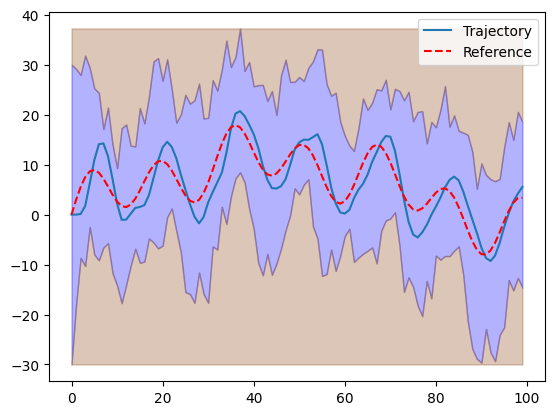

In [ ]:
# Import relevant modules
import sys, os
sys.path.append(os.path.abspath(".."))  # add parent dir

import numpy as np
import matplotlib.pyplot as plt
from uuv_mission.dynamic import Mission
from uuv_mission.dynamic import Submarine, ClosedLoop
from uuv_mission.controller import PDController

sub = Submarine()
controller = PDController(kp = 0.15, kd = 0.6)

closed_loop = ClosedLoop(sub, controller)
mission = Mission.from_csv("../data/mission.csv")

trajectory = closed_loop.simulate_with_random_disturbances(mission)
trajectory.plot_completed_mission(mission)

In [ ]:
# Parameter sweep over kp and kd, collecting average error
nseeds = 5

kp_grid = np.arange(0.0, 0.5, 0.005)
kd_grid = np.arange(0.0, 1.1, 0.005)
KP, KD = np.meshgrid(kp_grid, kd_grid)
Z = np.zeros_like(KP, dtype=float)

for i, kdval in enumerate(kd_grid):
    for j, kpval in enumerate(kp_grid):
        Z[i, j] = 0  # reset for each (kp, kd) pair
        for s in range(nseeds):  # average over 5 seeds
            sub = Submarine()
            controller = PDController(kp=kpval, kd=kdval)
            closed_loop = ClosedLoop(sub, controller)

            trajectory = closed_loop.simulate_with_random_disturbances(mission, seed = 100 + s)
            # compute avg error from closed_loop if available, otherwise estimate from trajectory
            try:
                avg_error = closed_loop.get_avg_error()
            except AttributeError:
                # fallback: use mean absolute error between reference and observed depth
                obs = trajectory.position[:, 1]  # y is depth
                ref = mission.reference[: len(obs)]
                avg_error = float(np.mean(np.abs(ref - obs)))

            Z[i, j] = Z[i, j] + avg_error

        Z[i, j] = np.log(Z[i, j] / nseeds)  # average over seeds

# Plot heatmap: KP on x-axis, KD on y-axis
plt.figure(figsize=(8, 5))
pcm = plt.pcolormesh(KD, KP, Z, shading='auto', cmap='viridis')
plt.colorbar(pcm, label='Log avg error')
plt.xlabel('kd')
plt.ylabel('kp')
plt.title('Average tracking error over (kp, kd)')
plt.tight_layout()
plt.show()

# Find the indices of the minimum value in Z
min_idx = np.unravel_index(np.argmin(Z), Z.shape)

# Extract the corresponding kp and kd values
best_kd = kd_grid[min_idx[0]]   # row index → kd
best_kp = kp_grid[min_idx[1]]   # column index → kp

# Print results
print(f"Minimum log error: {Z[min_idx]:.4f}")
print(f"Best kp = {best_kp:.3f}, Best kd = {best_kd:.3f}")

KeyboardInterrupt: 

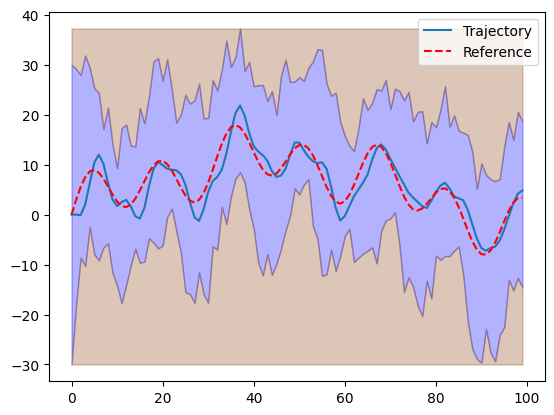

In [ ]:
#Visually inspect best parameters
sub = Submarine()
controller = PDController(kp = 0.055, kd = 0.845)

closed_loop = ClosedLoop(sub, controller)
mission = Mission.from_csv("../data/mission.csv")

trajectory = closed_loop.simulate_with_random_disturbances(mission)
trajectory.plot_completed_mission(mission)